## **Active Learning**

Using `twinLab`, we can easily build a surrogate model of some real-world physical processes using limited experimental data. The discrepancy between this surrogate model and the real process is described by the (calibrated) uncertainty estimate produced our models. This way, inference activities while using the surrogate model can be supported by well-grounded evidence of the model _correctness_. In areas of high model uncertainty, one must then take care to not be overly trusting of the model output, which is especially important for safety-critical applications.

In scenarios of high model uncertainty, one useful activity is to improve the model by collecting additional data. Here, **Active Learning** (also known as _Design of Experiments_ or _Optimal Experimental Design_) as it is presented in `twinLab` answers the question of how best to obtain new experimental data, in order to build a surrogate which is _most accurate_ while _requiring the least amount of data_.

This notebook will cover:

- Using Active Learning to iteratively improve a surrogate model in `twinLab`


In [1]:
# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# twinLab import
import twinlab as tl


          ====== TwinLab Client Initialisation ======
          Version     : 2.2.0
          Server      : https://5utl2p4lff.execute-api.eu-west-2.amazonaws.com/dev
          Environment : /Users/sergiochavez/twinlab-demos/.env



### **1-Dimensional example**

We first begin with a one-dimensional example. Consider the following function:


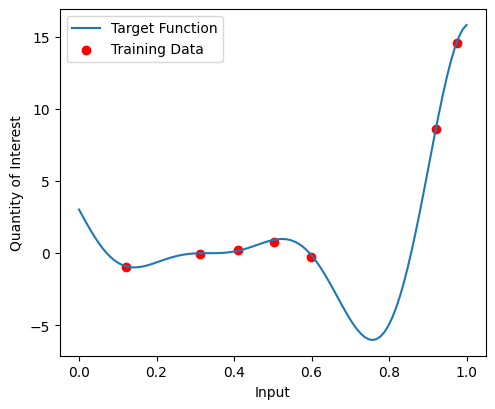

In [2]:
# Target function: forrester function
def f(x, a=6, b=12):
    return (a * x - 2) ** 2 * np.sin(b * x - 4)


X = np.linspace(0, 1, 100)[:, np.newaxis]
y = f(X)  # Arrange outputs as feature columns

# Set up training data dataframe
X_data = np.array([0.12, 0.311, 0.409, 0.502, 0.598, 0.921, 0.9765])
y_data = []
for i in X_data:
    y_data.append(f(i) + np.random.normal(scale=0.1))

# Plot
plt.figure(figsize=(5.5, 4.5))
plt.plot(X, y, label="Target Function")
plt.scatter(X_data, y_data, color="red", label="Training Data")
plt.xlabel("Input")
plt.ylabel("Quantity of Interest")
plt.legend()
plt.show()

Imagine that the process to obtain this training data was so painstaking that we only managed 6 data samples from initial experiments. The (material or computational) costs may be prohibitively expensive to obtain many more experiments, but we would like to model this (very limited) experimental data nonetheless. We now use `Emulator.train` to build an initial surrogate:


In [3]:
# Convert to DataFrame
df_train = pd.DataFrame({"X": X_data, "y": y_data})
df_test = pd.DataFrame({"X": X.flatten(), "y": y.flatten()})

# Define the name of the dataset
dataset_id = "Training_Data"

dataset_1D = tl.Dataset(id=dataset_id)

# Upload the dataset to the cloud
dataset_1D.upload(df_train, verbose=True)

Dataframe is uploading.
Processing dataset
Dataset Training_Data was processed.


In [4]:
# Initialise emulator
emulator_id = "basic_emulator"

emulator = tl.Emulator(id=emulator_id)

# Train the emulator using the train method
emulator.train(dataset=dataset_1D, inputs=["X"], outputs=["y"], verbose=True)

Model basic_emulator has begun training.
Training complete!


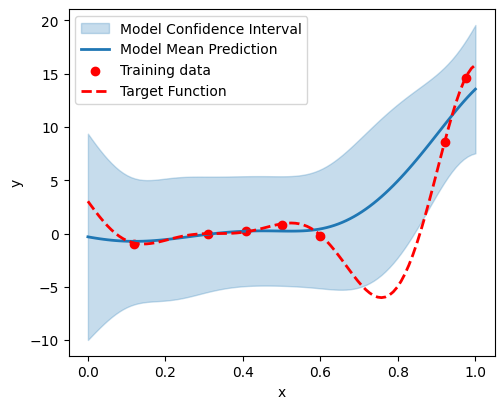

In [5]:
# Plot inference results
predictions = emulator.predict(df_test)
result_df = pd.concat([predictions[0], predictions[1]], axis=1)
df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
y_mean, y_stdev = df_mean.values, df_stdev.values

plt.figure(figsize=(5.5, 4.5))
plt.fill_between(
    X.flatten(),
    (y_mean - 2.58 * y_stdev).flatten(),
    (y_mean + 2.58 * y_stdev).flatten(),
    color="C0",
    alpha=0.25,
    label="Model Confidence Interval",
)
plt.plot(X, y_mean, c="C0", linewidth=2, label="Model Mean Prediction")

plt.scatter(df_train["X"], df_train["y"], color="red", label="Training data")
plt.xlabel("x")
plt.ylabel("y")

plt.plot(X, y, c="r", linewidth=2, linestyle="dashed", label="Target Function")
plt.legend()
plt.show()

Not a bad statistical model of 6 data samples, however we can see that the model does not line up exactly right with the true function in some areas. In this one-dimensional example, a human observer can pretty easily see that a new data sample should be obtained around `x=0.8`. However, when each data sample is so expensive to obtain, 'around' `x=...` may not be a good enough estimate. Furthermore, above two output dimensions it becomes very difficult for the human observer to visualise the model uncertainty.

The short explanation of our Bayesian active learning algorithm is that it programmatically suggests the locations where the model uncertainty is highest, and suggest these as the new sample locations. First we will write a script defining an iteration of the following active learning loop:

1. Build surrogate on currently available data
2. Call `Emulator.recommend(num_points=n, acq_func="ExpectedImprovement")`, with `n` being the number of desired sample locations and `acq_func` denotes the acquisition function used to sample new points. For active learning, the acquisition function used is `"ExpectedImprovement"`.
3. Collect data at suggested locations (from experiment or simulator codes)
4. Add new data to currently available data

Steps (1) to (4) can be repeated infinitely, or more likely until the sampling budget is exhausted or the surrogate model passes some metric of accuracy.


In [6]:
# Write a helper function
def active_learning(df_train, df_test=df_test, emulator=emulator, num_samples=1):
    X_test = df_test["X"].values

    # Get current model predictions
    predictions = emulator.predict(df_test)
    result_df = pd.concat([predictions[0], predictions[1]], axis=1)
    df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
    y_mean, y_stdev = df_mean.values.flatten(), df_stdev.values.flatten()

    # Compute optimal sample location(s)
    df_new = emulator.recommend(
        num_points=num_samples, acq_func="ExpectedImprovement"
    )
    print("Suggested Data Point(s):")
    display(df_new)
    # Evaluate new data points
    df_new["y"] = f(df_new["X"].values) + np.random.normal(scale=0.1, size=num_samples)

    # Plot current model predictions
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    # Plot the previous trained model and the suggested data point(s)
    ax1.fill_between(
        X_test,
        y_mean + 2.58 * y_stdev,
        y_mean - 2.58 * y_stdev,
        color="C0",
        alpha=0.25,
        label="Model Confidence Bound",
    )
    ax1.plot(df_test["X"], y_mean, color="C0", label="Mean Prediction")
    ax1.scatter(df_train["X"], df_train["y"], color="red", label="Training Data")
    ax1.plot(
        df_test["X"],
        df_test["y"],
        color="red",
        linestyle="dashed",
        label="Target Function",
    )
    ax1.vlines(
        df_new["X"],
        ymin=-10,
        ymax=20,
        color="gray",
        linestyle="dashed",
        alpha=0.8,
        label="Recommended sample location",
    )
    ax1.set_title("Current Model")
    ax1.set_xlim(0, 1)
    ax1.set_xlabel("Input")
    ax1.set_ylabel("Quantity of Interest")
    # ax1.legend(loc="upper left")

    # Train model with new data
    df_train = pd.concat([df_train, df_new], ignore_index=True)

    # Upload training dataframe
    dataset_id = "Training_Data"

    new_dataset = tl.Dataset(id=dataset_id)

    new_dataset.upload(df_train, verbose=True)

    # Start a new campaign and train a surrogate model
    emulator.train(dataset=new_dataset, inputs=["X"], outputs=["y"])

    predictions = emulator.predict(df_test)
    result_df = pd.concat([predictions[0], predictions[1]], axis=1)
    df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
    y_mean, y_stdev = df_mean.values.flatten(), df_stdev.values.flatten()
    ax2.fill_between(
        df_test["X"],
        y_mean + 2.58 * y_stdev,
        y_mean - 2.58 * y_stdev,
        color="C0",
        alpha=0.25,
        label="Confidence Bound",
    )
    ax2.plot(df_test["X"], y_mean, color="C0", label="Mean Prediction")
    ax2.scatter(
        df_train["X"][:-num_samples],
        df_train["y"][:-num_samples],
        color="red",
        label="Training Data",
    )
    ax2.plot(
        df_test["X"],
        df_test["y"],
        color="red",
        linestyle="dashed",
        label="Target Function",
    )
    ax2.scatter(
        df_train["X"][len(df_train) - num_samples :],
        df_train["y"][len(df_train) - num_samples :],
        color="gray",
        label="Recommended Sample",
    )
    ax2.set_title("Next Model")
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("Input")
    ax2.set_ylabel("Quantity of Interest")
    ax2.legend(loc="upper left")

    plt.show()

    return df_train

With this script, we can now run an iteration of the active learning loop:


Suggested Data Point(s):


,X
0,0.9765


Dataframe is uploading.
Processing dataset
Dataset Training_Data was processed.


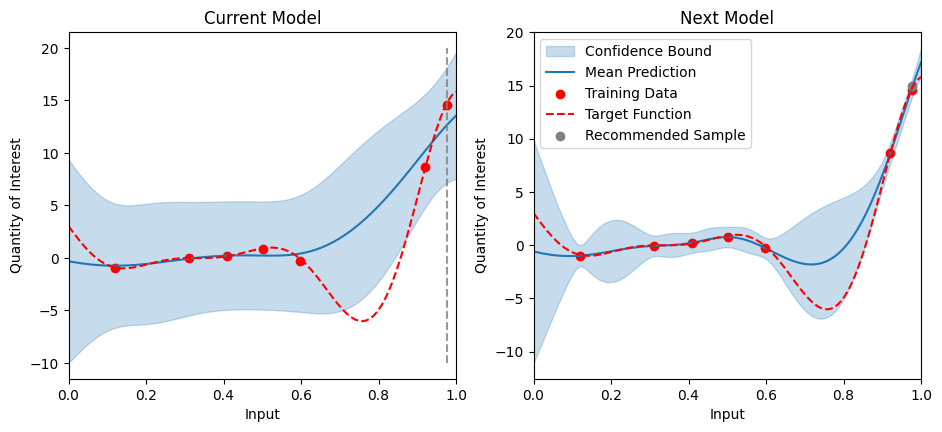

In [7]:
df_train = active_learning(
    df_train, df_test=df_test, emulator=emulator, num_samples=1
)

Our algorithm suggests that the next location to sample is `x≈0.215`. Already, the model is much better than before. If we can afford to, we may request another sample location, or stop here.


Suggested Data Point(s):


,X
0,0.9765


Dataframe is uploading.
Processing dataset
Dataset Training_Data was processed.


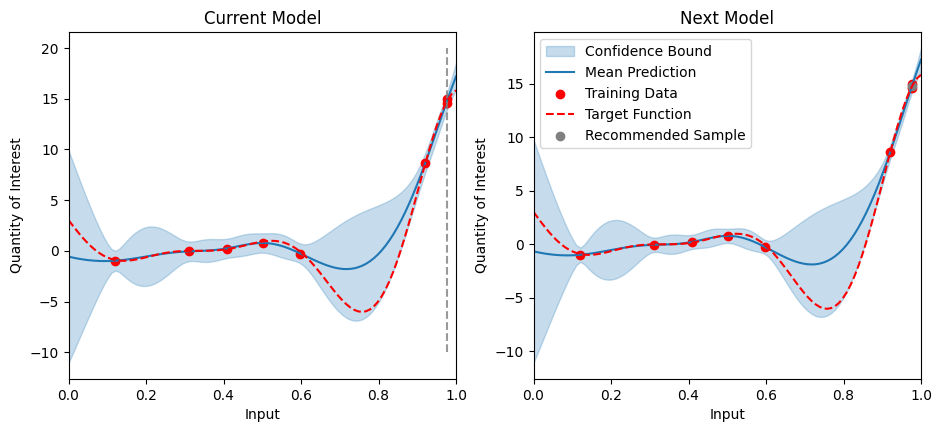

In [8]:
df_train = active_learning(
    df_train, df_test=df_test, emulator=emulator, num_samples=1
)

In [9]:
# Delete the emulator and dataset
emulator.delete()
dataset_1D.delete()

### **2-Dimensional Example**

Even in the previous one-dimensional example, it is difficult for a human observer to accurately determine the location of maximal model uncertainty. In this example, we demonstrate the difficulty of scaling up the 'human expert' with a two-dimensional example.


In [11]:
# Define a non-linear, 2D function
def target_function(x, y):
    # Branin function
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a * (y - b * x**2 + c * x - r) ** 2 + s * (1 - t) * np.cos(x) + s


# Plotting function
def plot_function(
    xx,
    yy,
    zz,  # Background grid
    zz_pred=None,
    zz_stdv=None,  # Mean and uncertainty in model function
    x_org=None,
    y_org=None,
    z_org=None,  # Original training data
    x_new=None,
    y_new=None,
    z_new=None,  # New training data
    x_upd=None,
    y_upd=None,  # Proposed candidate points
    show_truth=True,  # Show true function
):
    cmap_fn, cmap_std = "YlGn", "Blues"
    alpha_fn, alpha_std = 0.8, 1.0
    levels = 20
    color_org, color_new, color_upd = "black", "blue", "red"
    marker_org, marker_new, marker_upd = "x", "x", "x"
    marker_col = "o"
    vmin, vmax = zz.min(), zz.max()
    figx, figy = 4, 4

    # Set layout
    if zz_pred is None and zz_stdv is None:
        rows, cols = 1, 1
    else:
        rows, cols = 1, 3
    _, axs = plt.subplots(rows, cols, figsize=(cols * figx, rows * figy))

    if rows == 1 and cols == 1:
        axs = np.array([axs])
    axs = np.atleast_2d(axs)
    for ax in axs.flatten():
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_aspect("equal")

    # Plot true function
    if show_truth:
        axs[0, 0].set_title("True function")
        axs[0, 0].contourf(
            xx,
            yy,
            zz,
            cmap=cmap_fn,
            levels=levels,
            alpha=alpha_fn,
            vmin=vmin,
            vmax=vmax,
        )
    else:
        axs[0, 0].set_title("True function (unknown)")
        axs[0, 0].set_facecolor("lightgrey")

    if (
        x_org is not None and y_org is not None and z_org is not None
    ):  # Plot original points
        if show_truth:
            axs[0, 0].scatter(
                x_org, y_org, c=color_org, marker=marker_org, label="Original samples"
            )
        else:
            axs[0, 0].scatter(
                x_org,
                y_org,
                c=z_org,
                marker=marker_col,
                cmap=cmap_fn,
                vmin=vmin,
                vmax=vmax,
                label="Original samples",
            )
        axs[0, 0].legend(loc="upper left")

    if x_new is not None and y_new is not None and z_new is not None:  # Plot new points
        color = color_new if show_truth else z_new
        marker = marker_new if show_truth else marker_col
        axs[0, 0].scatter(
            x_new, y_new, c=color, marker=marker, cmap=cmap_fn, vmin=vmin, vmax=vmax
        )
        axs[0, 0].legend(loc="upper left")

    # Plot mean prediction
    if zz_pred is not None and zz_stdv is not None:
        axs[0, 1].set_title("Model function")
        axs[0, 1].contourf(
            xx,
            yy,
            zz_pred,
            cmap=cmap_fn,
            levels=levels,
            alpha=alpha_fn,
            vmin=vmin,
            vmax=vmax,
        )
        axs[0, 2].set_title("Model uncertainty")
        axs[0, 2].contourf(
            xx, yy, zz_stdv, cmap=cmap_std, levels=levels, alpha=alpha_std
        )
        if x_org is not None:  # Plot original points
            axs[0, 1].scatter(x_org, y_org, c=color_org, marker=marker_org)
            axs[0, 2].scatter(x_org, y_org, c=color_org, marker=marker_org)
            if rows == 2:
                axs[1, 1].scatter(x_org, y_org, c=color_org, marker=marker_org)
                axs[1, 2].scatter(x_org, y_org, c=color_org, marker=marker_org)
        if x_new is not None:  # Plot new points
            axs[0, 1].scatter(
                x_new, y_new, c=color_new, marker=marker_new, label="New samples"
            )
            axs[0, 2].scatter(x_new, y_new, c=color_new, marker=marker_new)
            if rows == 2:
                axs[1, 1].scatter(x_new, y_new, c=color_new, marker=marker_new)
                axs[1, 2].scatter(x_new, y_new, c=color_new, marker=marker_new)
            axs[0, 1].legend(loc="upper left")
        if x_upd is not None:  # Plot candidate points
            axs[0, 2].scatter(
                x_upd,
                y_upd,
                c=color_upd,
                marker=marker_upd,
                label="Recommended future samples",
            )
            axs[0, 2].legend(loc="upper left")
            if rows == 2:
                axs[1, 2].scatter(x_upd, y_upd, c=color_upd, marker=marker_upd)

    plt.tight_layout()
    plt.show()

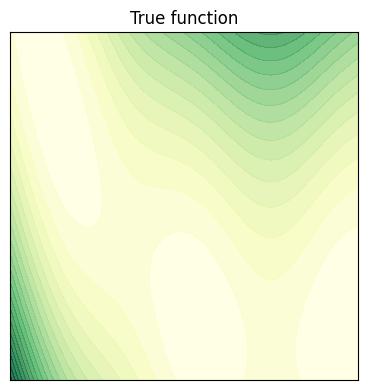

In [12]:
# Seed the random-number generator
seed = 4
np.random.seed(seed)
nmesh = 101
xmin, xmax = -5, 10
ymin, ymax = 0, 15

# Generate a grid of points and evaluate the function at each point
x, y = np.linspace(xmin, xmax, nmesh), np.linspace(ymin, ymax, nmesh)
xx, yy = np.meshgrid(x, y)
zz = target_function(xx, yy)

# Generate noisy train data
n_train = 9
err = 0.1
x_train = np.random.uniform(xmin, xmax, n_train)
y_train = np.random.uniform(ymin, ymax, n_train)
z_train = np.random.normal(target_function(x_train, y_train), err, n_train)

# Number of new data points to generate each iteration
n_candidates = 3

# Plot the data points
plot_function(xx, yy, zz, x_org=x_train, y_org=y_train)

# Convert to dataframes
df_train = pd.DataFrame(
    {"x": x_train.flatten(), "y": y_train.flatten(), "z": z_train.flatten()}
)
df_test = pd.DataFrame({"x": xx.flatten(), "y": yy.flatten(), "z": zz.flatten()})

In [13]:
# Define the name of the dataset
dataset_id = "2DActive_Data"

dataset_2D = tl.Dataset(id=dataset_id)

# Upload the dataset to the cloud
dataset_2D.upload(df_train, verbose=True)

Dataframe is uploading.
Processing dataset
Dataset 2DActive_Data was processed.


In [14]:
# Initialise campaign
emulator_id = "2DActiveGP"

new_emulator = tl.Emulator(id=emulator_id)

# Train the emulator using the train method
new_emulator.train(dataset=dataset_2D, inputs=["x", "y"], outputs=["z"], verbose=True)

# Get predictions on the test data
predictions = new_emulator.predict(df_test)
result_df = pd.concat([predictions[0], predictions[1]], axis=1)
df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
y_mean, y_stdev = df_mean.values, df_stdev.values

Model 2DActiveGP has begun training.
Training complete!


Now we can write our loop function...


In [16]:
def suggest_sample(
    emulator, df_train, df_test, n_candidates, df_new=None, show_truth=True
):
    # Plot inference results
    predictions = emulator.predict(df_test)
    result_df = pd.concat([predictions[0], predictions[1]], axis=1)
    df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
    z_mean, z_stdev = df_mean.values, df_stdev.values

    x_org, y_org, z_org = (
        df_train["x"].values,
        df_train["y"].values,
        df_train["z"].values,
    )
    if df_new is not None:
        x_new, y_new = df_new["x"].values, df_new["y"].values
        z_new = df_new["z"].values
    else:
        x_new, y_new, z_new = None, None, None

    # Get new candidate points 
    df_new = emulator.recommend(
        num_points=n_candidates, acq_func="ExpectedImprovement"
    )
    x_upd, y_upd = df_new.iloc[:, 0], df_new.iloc[:, 1]

    # Plot sample location
    plot_function(
        xx,
        yy,
        zz,
        z_mean.reshape((nmesh, nmesh)),
        z_stdev.reshape((nmesh, nmesh)),
        x_org=x_org,
        y_org=y_org,
        z_org=z_org,
        x_new=x_new,
        y_new=y_new,
        z_new=z_new,
        x_upd=x_upd,
        y_upd=y_upd,
        show_truth=show_truth,
    )

    # Sample at new location(s)
    z_upd = np.random.normal(target_function(x_upd, y_upd), 0.1)

    # Add new sample(s) to training data
    df_upd = pd.DataFrame({"x": x_upd, "y": y_upd, "z": z_upd})
    df_train = pd.concat([df_train, df_upd])

    new_dataset = tl.Dataset(id="new_points")

    new_dataset.upload(df_train)

    # Start a new campaign and train a surrogate model
    emulator.train(dataset=new_dataset, inputs=["x", "y"], outputs=["z"])

    return df_train

In [17]:
def suggest_sample2(
    emulator, df_train, df_test, n_candidates, df_new=None, show_truth=True
):
    # Plot inference results
    predictions = emulator.predict(df_test)
    result_df = pd.concat([predictions[0], predictions[1]], axis=1)
    df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
    z_mean, z_stdev = df_mean.values, df_stdev.values

    x_org, y_org, z_org = (
        df_train["x"].values,
        df_train["y"].values,
        df_train["z"].values,
    )
    if df_new is not None:
        x_new, y_new = df_new["x"].values, df_new["y"].values
        z_new = df_new["z"].values
    else:
        x_new, y_new, z_new = None, None, None

    # Get new candidate points 
    for i in range(5):
        emulator.train(dataset=dataset_2D, inputs=["x", "y"], outputs=["z"], verbose=True)
        if i < 4:
            candidate_points=emulator.recommend(num_points=1, acq_func="ExpectedImprovement")
            print("Iteration: ", i)
            print("Suggested Data Point(s):",candidate_points)
    _f = lambda x, cols: target_function(*[x[col] for col in cols]) 
    candidate_point_outputs = candidate_points.apply(_f, axis=1, cols=["x", "y"])
    candidate_points = pd.concat([candidate_points, candidate_point_outputs], axis=1)
    # candidate_points.columns = ["x", "y", "z"]

    # df_new = emulator.recommend(
    #     num_points=n_candidates, acq_func="ExpectedImprovement"
    # )
    x_upd, y_upd = candidate_points.iloc[:, 0], candidate_points.iloc[:, 1]

    # Plot sample location
    plot_function(
        xx,
        yy,
        zz,
        z_mean.reshape((nmesh, nmesh)),
        z_stdev.reshape((nmesh, nmesh)),
        x_org=x_org,
        y_org=y_org,
        z_org=z_org,
        x_new=x_new,
        y_new=y_new,
        z_new=z_new,
        x_upd=x_upd,
        y_upd=y_upd,
        show_truth=show_truth,
    )

    # Sample at new location(s)
    z_upd = np.random.normal(target_function(x_upd, y_upd), 0.1)

    # Add new sample(s) to training data
    df_upd = pd.DataFrame({"x": x_upd, "y": y_upd, "z": z_upd})
    df_train = pd.concat([df_train, df_upd])

    new_dataset = tl.Dataset(id="new_points")

    new_dataset.upload(df_train)

    # Start a new campaign and train a surrogate model
    emulator.train(dataset=new_dataset, inputs=["x", "y"], outputs=["z"])

    return df_train

In [35]:
def target_function(x, y):
    # Branin function
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a * (y - b * x**2 + c * x - r) ** 2 + s * (1 - t) * np.cos(x) + s

_f = lambda x, cols: target_function(*[x[col] for col in cols]) 

_f(z_train, cols=["x", "y"])


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [23]:
# Define a non-linear, 2D function
def target_function(x, y):
    # Branin function
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a * (y - b * x**2 + c * x - r) ** 2 + s * (1 - t) * np.cos(x) + s

def suggest_sample3(
    emulator, df_train, df_test, n_candidates, df_new=None, show_truth=True
):
    # Plot inference results
    predictions = emulator.predict(df_test)
    result_df = pd.concat([predictions[0], predictions[1]], axis=1)
    df_mean, df_stdev = result_df.iloc[:, 0], result_df.iloc[:, 1]
    z_mean, z_stdev = df_mean.values, df_stdev.values

    x_org, y_org, z_org = (
        df_train["x"].values,
        df_train["y"].values,
        df_train["z"].values,
    )
    if df_new is not None:
        x_new, y_new = df_new["x"].values, df_new["y"].values
        z_new = df_new["z"].values
    else:
        x_new, y_new, z_new = None, None, None

    # Get new candidate points 
    
    _f = lambda x, cols: target_function(*[x[col] for col in cols])
    emulator.learn(dataset=dataset_2D, inputs=["x", "y"], outputs=["z"],
                   num_loops=3, num_points_per_loop=1, acq_func="ExpectedImprovement",simulation=emulator.recommend(num_points=n_candidates, acq_func="ExpectedImprovement").apply(_f, axis=1, cols=["x", "y"]))
    df_new = emulator.recommend(
        num_points=n_candidates, acq_func="ExpectedImprovement"
    )
    x_upd, y_upd = df_new.iloc[:, 0], df_new.iloc[:, 1]

    # Plot sample location
    plot_function(
        xx,
        yy,
        zz,
        z_mean.reshape((nmesh, nmesh)),
        z_stdev.reshape((nmesh, nmesh)),
        x_org=x_org,
        y_org=y_org,
        z_org=z_org,
        x_new=x_new,
        y_new=y_new,
        z_new=z_new,
        x_upd=x_upd,
        y_upd=y_upd,
        show_truth=show_truth,
    )

    # Sample at new location(s)
    z_upd = np.random.normal(target_function(x_upd, y_upd), 0.1)

    # Add new sample(s) to training data
    df_upd = pd.DataFrame({"x": x_upd, "y": y_upd, "z": z_upd})
    df_train = pd.concat([df_train, df_upd])

    new_dataset = tl.Dataset(id="new_points")

    new_dataset.upload(df_train)

    # Start a new campaign and train a surrogate model
    emulator.train(dataset=new_dataset, inputs=["x", "y"], outputs=["z"])

    return df_train

In [39]:
target_function(emulator.recommend(num_points=1, acq_func="ExpectedImprovement"))

{'message': 'The model basic_emulator does not exist'}


KeyError: 'process_id not in API response body'

In [38]:
emulator.id

'basic_emulator'

Model 2DActiveGP has begun training.
Training complete!
Iteration:  0
Suggested Data Point(s):           x         y
0 -4.906546  4.926315
Model 2DActiveGP has begun training.
Training complete!
Iteration:  1
Suggested Data Point(s):           x         y
0 -4.906546  4.926236
Model 2DActiveGP has begun training.
Training complete!
Iteration:  2
Suggested Data Point(s):           x         y
0 -4.906546  4.926248
Model 2DActiveGP has begun training.
Training complete!
Iteration:  3
Suggested Data Point(s):           x         y
0 -4.906546  4.926259
Model 2DActiveGP has begun training.
Training complete!


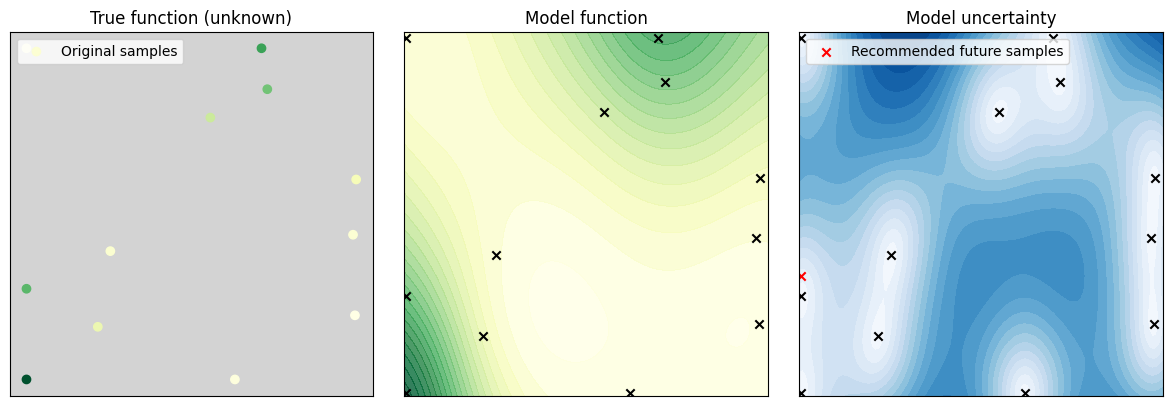

In [18]:
# Request a first set of candidates
_df_train = suggest_sample2(
    new_emulator, df_train, df_test, n_candidates=3, show_truth=False
)
df_new = _df_train[-3:]
df_train = _df_train

... and request the first set of candidate points.


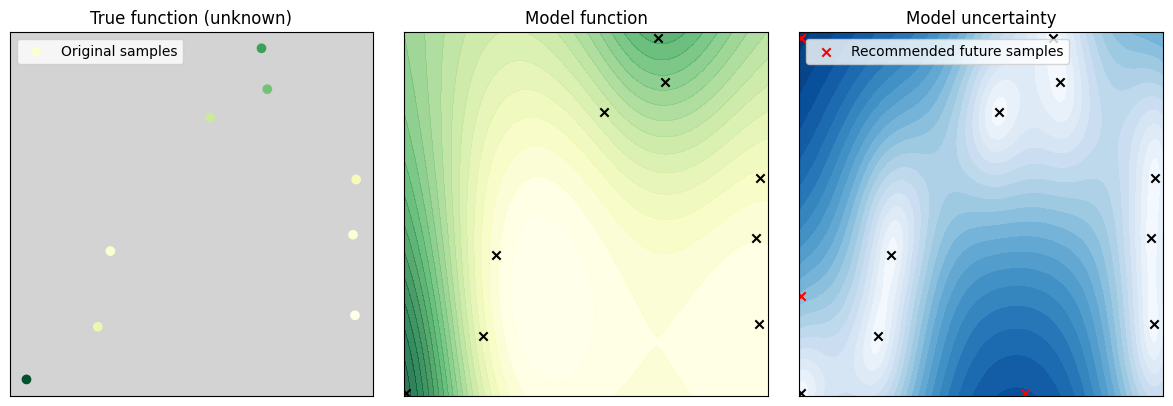

In [15]:
# Request a first set of candidates
_df_train = suggest_sample(
    new_emulator, df_train, df_test, n_candidates=3, show_truth=False
)
df_new = _df_train[-3:]
df_train = _df_train

In [24]:
# Request a first set of candidates
_df_train = suggest_sample3(
    new_emulator, df_train, df_test, n_candidates=3, show_truth=False
)
df_new = _df_train[-3:]
df_train = _df_train

iteration: 0, Suggested Candidate Point:           x         y
0 -4.906546  4.926253


TypeError: suggest_sample3.<locals>.<lambda>() missing 1 required positional argument: 'cols'

We can then request another set of points and view the impact of the last set.


In [ ]:
# Request another set of candidates
df_train = suggest_sample(
    new_emulator, df_train, df_test, n_candidates=3, df_new=df_new, show_truth=False
)

In [ ]:
# Delete emulator and dataset
new_emulator.delete()

dataset_2D.delete()

In [ ]:
# How it use to be    
@typechecked
    def learn(
        self,
        dataset: Dataset,
        inputs: List[str],
        outputs: List[str],
        num_loops: int,
        num_points_per_loop: int,
        acq_func: str,
        simulation: Callable,  # Something that ingests `df_X` and returns `df_y`
        train_params: Optional[TrainParams] = TrainParams(),
        recommend_params: Optional[RecommendParams] = RecommendParams(),
        sync: bool = False,
        ping_time_train: float = PING_TIME_TRAIN_DEFAULT,
        ping_time_recommend: float = PING_TIME_USE_DEFAULT,
        processor: str = PROCESSOR_DEFAULT,
        verbose: bool = False,
        debug: bool = False,
    ) -> None:
        """
        # Learn

        Perform learning to train an emulator on the `twinLab` cloud in a loop to demonstrate active learning and optimisation routines.

        ## Arguments:
        - `dataset`: `Dataset`. twinLab dataset object which contains the training data for the emulator.
        - `inputs`: `list[str]`. List of input names in the training dataset.
        - `outputs`; `list[str]`. List of output names in the training dataset.
        - `num_loops`: `int`. Number of loops to run the learning process.
        - `num_points_per_loop`: `int`. Number of points to sample in each loop.
        - `acq_func`: `str`. Specifies the acquisition function to be used when recommending new points; this can be chose from a list of possible fucntions:
            `"ExpectedImprovement"`, `"qExpectedImprovement"`, `"LogExpectedImprovement"`, `"qLogExpectedImprovement"`, `"PosteriorStandardDeviation"`, `"qNegIntegratedPosteriorVariance"`.
        - `simulation`: `Callable`. A function that takes in a set of inputs and generates the outputs(a simulator for the data generating process).
        - `train_params`: `TrainParams`, `optional`. A `TrainParams` object that contains all necessary training parameters.
        - `recommend_params`: `RecommendParams`, `optional`. A `RecommendParams` object that contains all recommendation parameters.
        - `sync`: `bool`, `optional`, determining whether to use synchronous or asynchronous method
        - `ping_time_train`: `float`, `optional`, time between pings to the server to check if the job is complete [s]
        - `ping_time_recommend`: `float`, `optional`, time between pings to the server to check if the job is complete [s]
        - `processor`: `str`, `optional`. Processor to use for sampling. Can be either `"cpu"` or `"gpu"`.
        - `verbose`: `bool`, `optional`. Determining level of information returned to the user.
        - `debug`: `bool`, `optional`. Determining level of information logged on the server.

        ## Example:

            ```python
            import pandas as pd
            import numpy as np

            import twinlab as tl

            grid = np.linspace(0, 1)

            # Defining the simulation function
            def model(x):
                return (x[0] * grid - 2) ** 2 * np.sin(x[1] * grid - 4)

            def generate_output(x):
                y = np.zeros((x.shape[0], grid.size))
                for i, x_i in enumerate(x):
                    y[i, :] = model(x_i)
                return y

            emulator_id = "my_emulator"
            dataset_id = "my_dataset"
            input_columns = ["x1", "x2"]
            output_columns = ["y_{}".format(i) for i in range(grid.size)]

            # Create emulator
            emulator = tl.Emulator(id=emulator_id)
            training_dataset = tl.Dataset(dataset_id)
            training_dataset.upload(df)

            params = tl.TrainParams(
                train_test_ratio=0.75,
                estimator="gaussian_process_regression",
                output_explained_variance=0.99999,
            )

            # Call the learn function
            emulator.learn(
                dataset=training_dataset,
                inputs=input_columns,
                outputs=output_columns,
                num_loops=1,
                num_points_per_loop=1,
                acq_func="EI",
                simulation=generate_output,
                train_params=params,
            )
            ```
        """

        for i in range(num_loops):

            # Train model
            self.train(
                dataset=dataset,
                inputs=inputs,
                outputs=outputs,
                params=train_params,
                ping_time=ping_time_train,
                processor=processor,
                verbose=verbose,
                debug=debug,
            )

            if i < num_loops - 1:

                # Compute optimal sample location(s)
                candidate_points = self.recommend(
                    num_points=num_points_per_loop,
                    acq_func=acq_func,
                    params=recommend_params,
                    sync=sync,
                    ping_time=ping_time_recommend,
                    processor=processor,
                    verbose=verbose,
                    debug=debug,
                )

                print(f"iteration: {i}, Suggested Candidate Point: {candidate_points}")

                # Evaluating the candidate points
                # num_args = len(inspect.signature(simulation).parameters)
                # if num_args == 1:
                candidate_points[outputs] = simulation(candidate_points[inputs].values)
                # else:
                #     _f = lambda x, cols: simulation(*[x[col] for col in cols])
                #     candidate_point_outputs = candidate_points.apply(
                #         _f, axis=1, cols=candidate_points.columns
                #     )
                #     candidate_points = pd.concat(
                #         [candidate_points, candidate_point_outputs],
                #         axis=1,
                #     )
                #     candidate_points.columns = inputs + outputs

                # Download current training data, append new data, and reupload
                df_train = self.view_train_data()
                df_train = pd.concat([df_train, candidate_points], ignore_index=True)
                dataset.upload(df_train)